## 1.Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load the Dataset

In [2]:
df = pd.read_csv('data/AirQualityUCI.csv',sep=';')
df = df.drop(columns=['Unnamed: 15','Unnamed: 16'])
y_target = 'PT08.S1(CO)'
df.head(5)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,"2,6",1360.0,150.0,"11,9",1046.0,166.0,1056.0,113.0,1692.0,1268.0,"13,6","48,9","0,7578"
1,10/03/2004,19.00.00,2,1292.0,112.0,"9,4",955.0,103.0,1174.0,92.0,1559.0,972.0,"13,3","47,7","0,7255"
2,10/03/2004,20.00.00,"2,2",1402.0,88.0,"9,0",939.0,131.0,1140.0,114.0,1555.0,1074.0,"11,9","54,0","0,7502"
3,10/03/2004,21.00.00,"2,2",1376.0,80.0,"9,2",948.0,172.0,1092.0,122.0,1584.0,1203.0,"11,0","60,0","0,7867"
4,10/03/2004,22.00.00,"1,6",1272.0,51.0,"6,5",836.0,131.0,1205.0,116.0,1490.0,1110.0,"11,2","59,6","0,7888"


## 3. Dataset Overview

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   object 
 1   Time           9357 non-null   object 
 2   CO(GT)         9357 non-null   object 
 3   PT08.S1(CO)    9357 non-null   float64
 4   NMHC(GT)       9357 non-null   float64
 5   C6H6(GT)       9357 non-null   object 
 6   PT08.S2(NMHC)  9357 non-null   float64
 7   NOx(GT)        9357 non-null   float64
 8   PT08.S3(NOx)   9357 non-null   float64
 9   NO2(GT)        9357 non-null   float64
 10  PT08.S4(NO2)   9357 non-null   float64
 11  PT08.S5(O3)    9357 non-null   float64
 12  T              9357 non-null   object 
 13  RH             9357 non-null   object 
 14  AH             9357 non-null   object 
dtypes: float64(8), object(7)
memory usage: 1.1+ MB


In [4]:
df.describe()

,PT08.S1(CO),NMHC(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3)
count,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1048.990061,-159.090093,894.595276,168.616971,794.990168,58.148873,1391.479641,975.072032
std,329.832710,139.789093,342.333252,257.433866,321.993552,126.940455,467.210125,456.938184
min,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,921.000000,-200.000000,711.000000,50.000000,637.000000,53.000000,1185.000000,700.000000
50%,1053.000000,-200.000000,895.000000,141.000000,794.000000,96.000000,1446.000000,942.000000
75%,1221.000000,-200.000000,1105.000000,284.000000,960.000000,133.000000,1662.000000,1255.000000
max,2040.000000,1189.000000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000


In [5]:
df.describe(include='object')

,Date,Time,CO(GT),C6H6(GT),T,RH,AH
count,9357,9357,9357,9357,9357,9357,9357
unique,391,24,104,408,437,754,6684
top,03/04/2005,18.00.00,-200,"-200,0",-200,-200,-200
freq,24,390,1592,366,366,366,366


## 3.Missing & Duplicate Values Analysis

In [6]:
missing = pd.DataFrame({
    'Missing Count':df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum()/len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values(by='Missing Percentage',ascending=True)
print('Colmuns with Missing values')
missing

Colmuns with Missing values


,Missing Count,Missing Percentage
Date,114,1.2
Time,114,1.2
CO(GT),114,1.2
PT08.S1(CO),114,1.2
NMHC(GT),114,1.2
C6H6(GT),114,1.2
PT08.S2(NMHC),114,1.2
NOx(GT),114,1.2
PT08.S3(NOx),114,1.2
NO2(GT),114,1.2


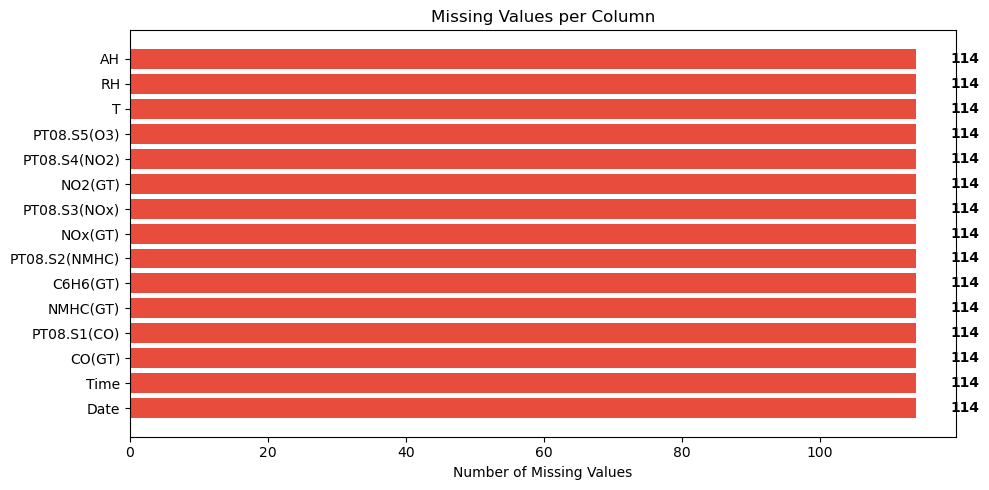

In [7]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(missing.index,missing['Missing Count'].values,color='#e74c3c')
ax.set_xlabel("Number of Missing Values")
ax.set_title("Missing Values per Column")
for i,v in enumerate(missing['Missing Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
duplicate = pd.DataFrame({
    'Duplicate Count':df.duplicated().sum(),
    'Duplicate Percentage': (df.duplicated().sum()/len(df) * 100).round(2)
},index=['Total Dataset'])
duplicate = duplicate[duplicate['Duplicate Count'] > 0].sort_values(by='Duplicate Percentage',ascending=True)
print('Colmuns with Duplicate values')
duplicate

Colmuns with Duplicate values


,Duplicate Count,Duplicate Percentage
Total Dataset,113,1.19


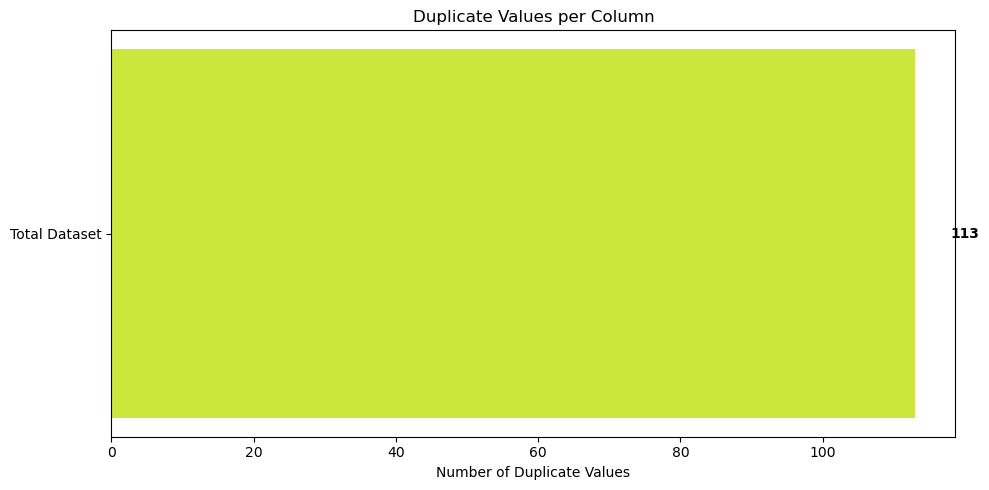

In [9]:
fig,ax = plt.subplots(figsize=(10,5))
ax.barh(duplicate.index,duplicate['Duplicate Count'].values,color="#cbe73c")
ax.set_xlabel("Number of Duplicate Values")
ax.set_title("Duplicate Values per Column")
for i,v in enumerate(duplicate['Duplicate Count'].values):
    if v > 0:
        ax.text(v+5,i,str(v),va='center',fontweight='bold')
plt.tight_layout()
plt.show()

## 4.Target Variabel Distribution

d:\all-packmanager-app\miniconda3\envs\Hafidz29Python\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


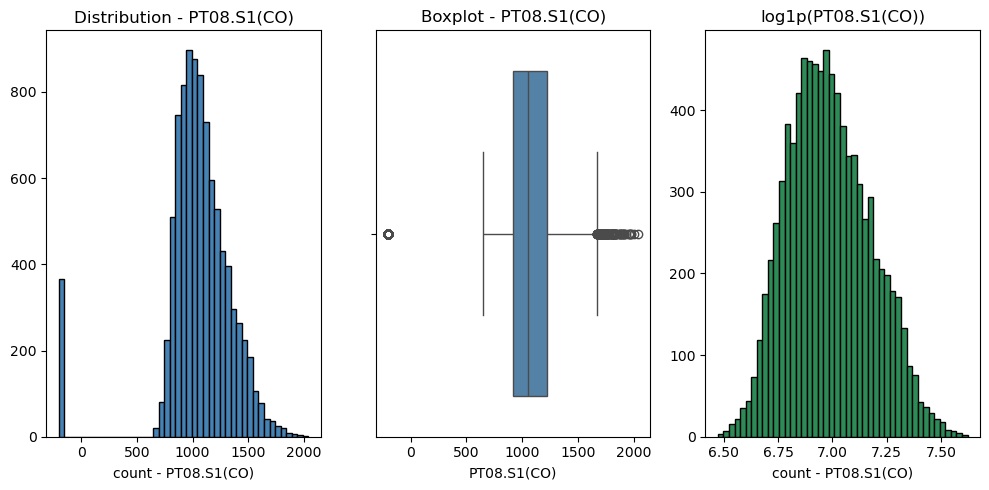

In [12]:
fig,axes = plt.subplots(1,3,figsize=(10,5))
axes[0].hist(df[y_target].dropna(),bins=45,color='steelblue',edgecolor='black')
axes[0].set_title(f'Distribution - {y_target}')
axes[0].set_xlabel(f'count - {y_target}')

sns.boxplot(x=df[y_target].dropna(),ax = axes[1],color='steelblue')
axes[1].set_title(f'Boxplot - {y_target}') 

axes[2].hist(np.log1p(df[y_target].dropna()),bins=45,color='seagreen',edgecolor='black')
axes[2].set_title(f'log1p({y_target})')
axes[2].set_xlabel(f'count - {y_target}')
plt.tight_layout()
plt.show()

In [13]:
describe = df[y_target].describe().round(3) #sudah berbentuk dataframe
y_stats = pd.DataFrame({
    y_target: [round(df[y_target].skew(), 3), round(df[y_target].kurtosis(), 3)]
},index=['Skewness', 'Kurtosis'])
df_stats = pd.concat([describe,y_stats]).T
df_stats

,count,mean,std,min,25%,50%,75%,max,Skewness,Kurtosis
PT08.S1(CO),9357.0,1048.99,329.833,-200.0,921.0,1053.0,1221.0,2040.0,-1.722,5.837
